In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# PARTIE 1 - ANALYSE EXPLORATOIRE COMPLETE

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print('\nSTATISTIQUES DESCRIPTIVES:')
print(df.describe())

print('\n'+'='*60)
print('REPARTITION PAR GENRE')
print('='*60)
print(df['Genre'].value_counts())
print('\nPourcentage:')
print((df['Genre'].value_counts(normalize=True) * 100).round(1))


STATISTIQUES DESCRIPTIVES:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

REPARTITION PAR GENRE
Genre
Female    112
Male       88
Name: count, dtype: int64

Pourcentage:
Genre
Female    56.0
Male      44.0
Name: proportion, dtype: float64


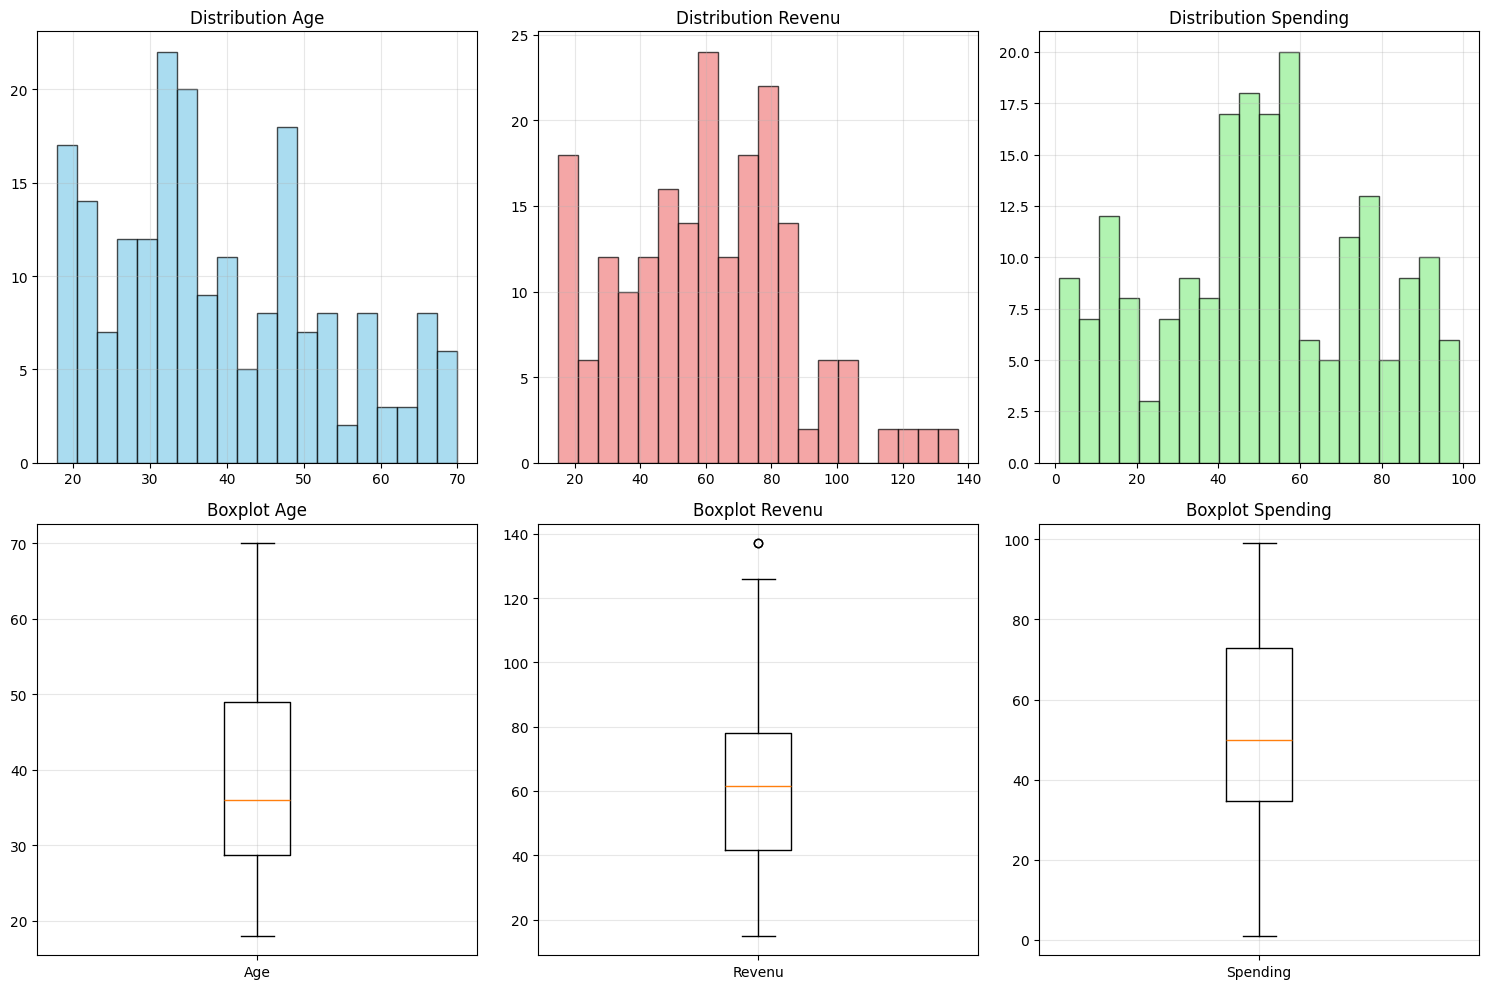

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].hist(df['Age'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Distribution Age')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 1].hist(df['Annual Income (k$)'], bins=20, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_title('Distribution Revenu')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 2].hist(df['Spending Score (1-100)'], bins=20, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 2].set_title('Distribution Spending')
axes[0, 2].grid(True, alpha=0.3)
axes[1, 0].boxplot([df['Age']], labels=['Age'])
axes[1, 0].set_title('Boxplot Age')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 1].boxplot([df['Annual Income (k$)']], labels=['Revenu'])
axes[1, 1].set_title('Boxplot Revenu')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 2].boxplot([df['Spending Score (1-100)']], labels=['Spending'])
axes[1, 2].set_title('Boxplot Spending')
axes[1, 2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

print('\n'+'='*60)
print('DETECTION DES OUTLIERS (Methode IQR)')
print('='*60)

for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    lower, upper = detect_outliers_iqr(df, col)
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'\n{col}:')
    print(f'  Limites: [{lower:.1f}, {upper:.1f}]')
    print(f'  Nombre outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')


DETECTION DES OUTLIERS (Methode IQR)

Age:
  Limites: [-1.6, 79.4]
  Nombre outliers: 0 (0.0%)

Annual Income (k$):
  Limites: [-13.2, 132.8]
  Nombre outliers: 2 (1.0%)

Spending Score (1-100):
  Limites: [-22.6, 130.4]
  Nombre outliers: 0 (0.0%)


# PARTIE 2 - PREPARATION DES DONNEES

In [8]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

print('='*60)
print('SELECTION DES FEATURES')
print('='*60)
print(f'Features: {features}')
print(f'Shape: {X.shape}')
print('\nPourquoi ces 2 variables:')
print('1. Annual Income: Pouvoir d achat client')
print('2. Spending Score: Comportement achat reel')
print('\nExclus:')
print('- CustomerID: Identifiant pur')
print('- Gender: Categorique (a analyser EN PLUS)')
print('- Age: Optionnel (partie 6)')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\n'+'='*60)
print('NORMALISATION')
print('='*60)
print('\nAVANT (moyennes et ecarts-types):')
print(X.describe().loc[['mean', 'std']])

print('\nAPRES (moyennes et ecarts-types):')
print(pd.DataFrame(X_scaled, columns=features).describe().loc[['mean', 'std']])

SELECTION DES FEATURES
Features: ['Annual Income (k$)', 'Spending Score (1-100)']
Shape: (200, 2)

Pourquoi ces 2 variables:
1. Annual Income: Pouvoir d achat client
2. Spending Score: Comportement achat reel

Exclus:
- CustomerID: Identifiant pur
- Gender: Categorique (a analyser EN PLUS)
- Age: Optionnel (partie 6)

NORMALISATION

AVANT (moyennes et ecarts-types):
      Annual Income (k$)  Spending Score (1-100)
mean           60.560000               50.200000
std            26.264721               25.823522

APRES (moyennes et ecarts-types):
      Annual Income (k$)  Spending Score (1-100)
mean       -2.131628e-16           -1.465494e-16
std         1.002509e+00            1.002509e+00


# PARTIE 3 - CHOIX DU K

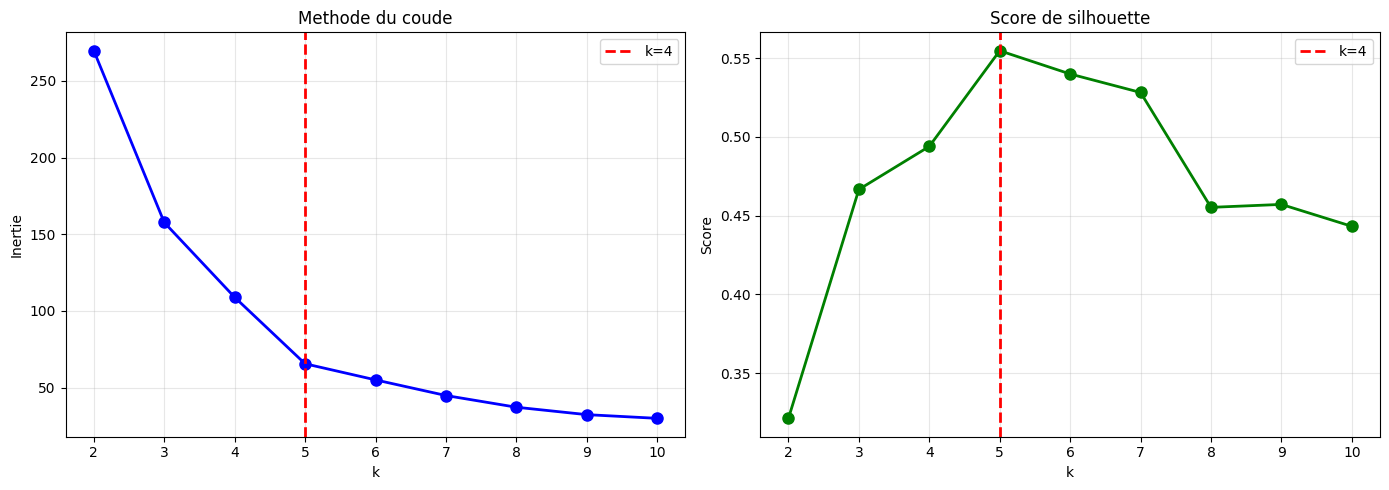

In [10]:
inertias = []
silhouette_scores = []

for k in range(2, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 11), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='k=4')
axes[0].set_title('Methode du coude')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(range(2, 11), silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2, label='k=4')
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# PARTIE 4 - K-MEANS CLUSTERING

RESULTATS CLUSTERING
Inertie: 65.57

Distribution par cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Pourcentage:
Cluster
0    40.5
1    19.5
2    11.0
3    17.5
4    11.5
Name: proportion, dtype: float64


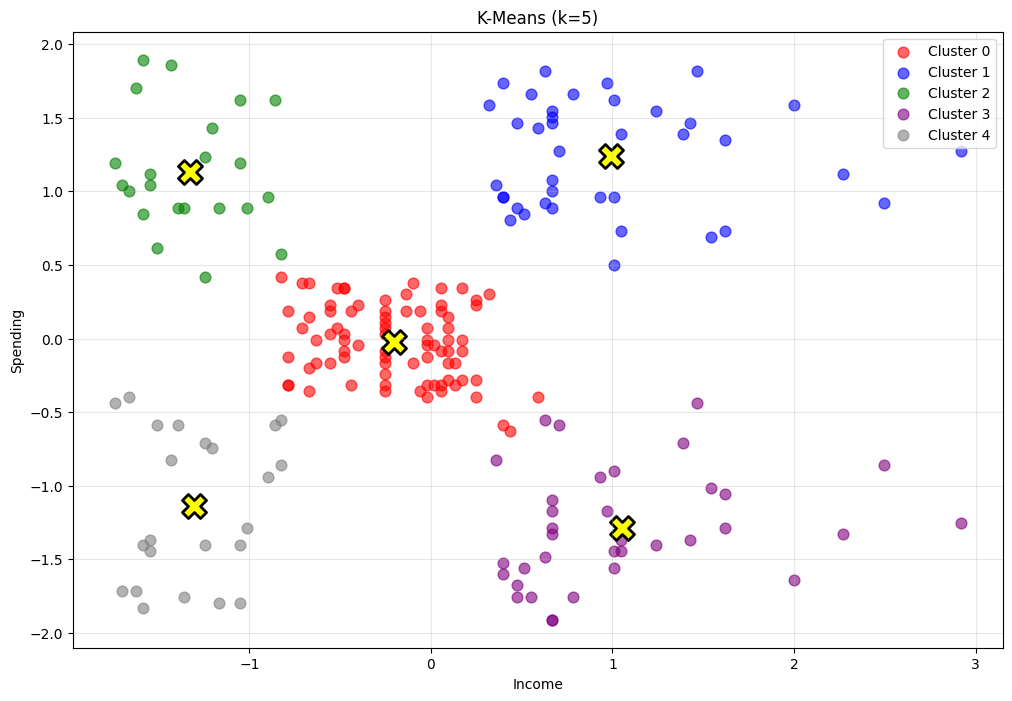

In [14]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

print('='*60)
print('RESULTATS CLUSTERING')
print('='*60)
print(f'Inertie: {kmeans.inertia_:.2f}')
print(f'\nDistribution par cluster:')
print(df['Cluster'].value_counts().sort_index())
print(f'\nPourcentage:')
print((df['Cluster'].value_counts(normalize=True).sort_index() * 100).round(1))

plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'purple', 'gray']
for i in range(optimal_k):
    mask = clusters == i
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1], c=colors[i], label=f'Cluster {i}', s=60, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='yellow', marker='X', s=300, edgecolors='black', linewidth=2)
plt.xlabel('Income')
plt.ylabel('Spending')
plt.title('K-Means (k=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
names = [
    "Revenus moderes + equilibres",
    "Hauts revenus + tres depensiers",
    "Bas revenus + tres depensiers",
    "Hauts revenus + prudents",
    "Bas revenus + prudents",
]

for i in range(optimal_k):
    c_df = df[df['Cluster'] == i]
    print(f'\nCLUSTER {i}: {names[i]}')
    print(f'  Clients: {len(c_df)} ({len(c_df)/len(df)*100:.1f}%)')
    print(f'  Revenu: {c_df["Annual Income (k$)"].mean():.1f}k$ (std: {c_df["Annual Income (k$)"].std():.1f})')
    print(f'  Spending: {c_df["Spending Score (1-100)"].mean():.1f} (std: {c_df["Spending Score (1-100)"].std():.1f})')
    print(f'  Age: {c_df["Age"].mean():.1f} ans')
    print(f'  Genre: {dict(c_df["Genre"].value_counts())}')


CLUSTER 0: Revenus moderes + equilibres
  Clients: 81 (40.5%)
  Revenu: 55.3k$ (std: 9.0)
  Spending: 49.5 (std: 6.5)
  Age: 42.7 ans
  Genre: {'Female': np.int64(48), 'Male': np.int64(33)}

CLUSTER 1: Hauts revenus + tres depensiers
  Clients: 39 (19.5%)
  Revenu: 86.5k$ (std: 16.3)
  Spending: 82.1 (std: 9.4)
  Age: 32.7 ans
  Genre: {'Female': np.int64(21), 'Male': np.int64(18)}

CLUSTER 2: Bas revenus + tres depensiers
  Clients: 22 (11.0%)
  Revenu: 25.7k$ (std: 7.6)
  Spending: 79.4 (std: 10.5)
  Age: 25.3 ans
  Genre: {'Female': np.int64(13), 'Male': np.int64(9)}

CLUSTER 3: Hauts revenus + prudents
  Clients: 35 (17.5%)
  Revenu: 88.2k$ (std: 16.4)
  Spending: 17.1 (std: 10.0)
  Age: 41.1 ans
  Genre: {'Male': np.int64(19), 'Female': np.int64(16)}

CLUSTER 4: Bas revenus + prudents
  Clients: 23 (11.5%)
  Revenu: 26.3k$ (std: 7.9)
  Spending: 20.9 (std: 13.0)
  Age: 45.2 ans
  Genre: {'Female': np.int64(14), 'Male': np.int64(9)}
